# Day 2 Project: 중고차 가격 데이터
-  "중고차 가격 예측 모델"이나 "중고차 특성에 따른 클러스터링"을 가정하여 데이터를 준비한다.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

car_df = pd.read_csv('data/cars.csv')
brand_df = pd.read_csv('data/brand.csv')

In [27]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 374.6+ KB


In [28]:
car_df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3662.000000,3652.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,4.321409,4.900329
std,4480.629885,3.941718e+04,5.082387,1.546028,0.986760,0.577046
min,400.000000,1.000000e+00,1953.000000,1.000000,2.000000,2.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,5.000000,7.000000


In [29]:
car_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [30]:
brand_df.shape

(48, 2)

In [31]:
brand_df.describe()

,title,country
count,48,48
unique,48,12
top,skoda,Japan
freq,1,11


In [15]:
brand_df.head()

,title,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States


## 1. cars.csv와 brand.csv의 데이터 합치기

In [ ]:
df_working = car_df.copy() # 원본 보호를 위한 복사본 생성

In [52]:
# brand_df 컬럼명 정리
brand_df.columns = ['brand', 'country']
# brand_df의 브랜드명도 대문자+공백제거
brand_df['brand'] = brand_df['brand'].str.upper().str.strip() #"이 글자들을 모두 대문자로 바꾸고, 혹시 모를 앞뒤 빈칸도 깔끔하게 지워서 brand라는 새 칸에 저장해."

# "제목(title) 칸에 있는 글자들을 딱 첫 번째 공백(' ')에서만 반으로 쪼개서, 두 개의 새로운 열을 가진 임시 표(split_data)를 만들어줘."
split_data = df_working['title'].str.split(' ', n=1, expand=True)   # n=1: "공백이 여러 개 있어도 상관 말고, 맨 앞에 나오는 첫 번째 공백에서만 딱 한 번 잘라!"라는 뜻입니다. (브랜드명과 모델명을 나누는 기준점)
df_working['brand'] = split_data[0].str.upper().str.strip()
df_working['model'] = split_data[1].str.upper().str.strip()
#"방금 쪼갠 것 중 왼쪽(0번) 데이터는 '브랜드'야. 이 글자들을 모두 대문자로 바꾸고, 혹시 모를 앞뒤 빈칸도 깔끔하게 지워서 brand라는 새 칸에 저장해."

In [40]:
# "자동차 목록(car_df)을 기준으로, 브랜드 이름(brand)이 일치하는 데이터를 찾아 brand_df에서 국가 정보를 가져와 왼쪽에 붙여줘. 만약 정보가 없는 브랜드라도 자동차 데이터는 지우지 말고 유지해줘."
merged_df = pd.merge(car_df, brand_df, on='brand', how='left')
merged_df.head()

,title,brand,model,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country
0,SKODA FABIA,SKODA,FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,NaN
1,VAUXHALL CORSA,VAUXHALL,CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,NaN
2,HYUNDAI I30,HYUNDAI,I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,NaN
3,MINI HATCH,MINI,HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,NaN
4,VAUXHALL CORSA,VAUXHALL,CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,NaN


In [54]:
# 결합 (how='left')
merged_df = pd.merge(df_working, brand_df, on='brand', how='left')
merged_df.head()

,title,brand,model,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country
0,SKODA FABIA,SKODA,FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,Czech Republic
1,VAUXHALL CORSA,VAUXHALL,CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,United Kingdom
2,HYUNDAI I30,HYUNDAI,I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,South Korea
3,MINI HATCH,MINI,HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,United Kingdom
4,VAUXHALL CORSA,VAUXHALL,CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,United Kingdom


## 3. 결측치 처리하기

#### 1. 'Previous Owners'


In [70]:
merged_df.isnull().sum()

title                   0
brand                   0
model                   0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners         0
Fuel type               0
Body type               0
Engine                 45
Gearbox                 0
Doors                  25
Seats                  35
Emission Class         87
Service history      3147
country                 0
dtype: int64

In [59]:
#Previous Owners      1411
merged_df['Previous Owners'].describe()

count    2276.000000
mean        2.807557
std         1.546028
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         9.000000
Name: Previous Owners, dtype: float64

In [62]:
merged_df['Previous Owners'].value_counts(dropna=False)

Previous Owners
NaN    1411
2.0     594
1.0     523
3.0     475
4.0     360
5.0     208
6.0      60
7.0      39
8.0      12
9.0       5
Name: count, dtype: int64

In [ ]:
######## 결측치가 많은 'Previous Owners'는 median 값으로 대치 (평균과 median이 근사함) ########
merged_df['Previous Owners']= merged_df['Previous Owners'].fillna(merged_df['Previous Owners'].median())
merged_df['Previous Owners'].value_counts(dropna=False)

Previous Owners
3.0    1886
2.0     594
1.0     523
4.0     360
5.0     208
6.0      60
7.0      39
8.0      12
9.0       5
Name: count, dtype: int64

#### 2. Engine

In [71]:
merged_df['Engine'].value_counts(dropna=False)


Engine
1.6L    736
2.0L    553
1.2L    521
1.4L    421
1.0L    326
1.5L    294
1.3L    170
1.8L    158
3.0L     79
2.2L     75
2.1L     63
NaN      45
1.1L     39
1.7L     35
2.5L     33
1.9L     31
2.4L     28
0.9L     15
2.7L     11
3.5L     10
3.2L      7
3.7L      5
4.4L      5
2.6L      4
2.3L      4
4.2L      4
2.8L      3
5.0L      3
0.8L      2
4.3L      2
3.1L      1
3.3L      1
5.5L      1
4.8L      1
6.3L      1
Name: count, dtype: int64

In [ ]:
# 데이터 정제: 'L' 제거 후 실수(float) 타입으로 변환
# keyword argument인 regex=False를 사용하여 단순 문자열 치환임을 명시
merged_df['Engine'] = merged_df['Engine'].str.replace('L', '', regex=False).astype(float)
merged_df.head()


,title,brand,model,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country
0,SKODA FABIA,SKODA,FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4,Manual,5.0,5.0,Euro 6,NaN,Czech Republic
1,VAUXHALL CORSA,VAUXHALL,CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2,Manual,3.0,5.0,Euro 4,Full,United Kingdom
2,HYUNDAI I30,HYUNDAI,I30,949,137000,2011,3.0,Petrol,Hatchback,1.4,Manual,5.0,5.0,Euro 5,NaN,South Korea
3,MINI HATCH,MINI,HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4,Manual,3.0,4.0,Euro 4,Full,United Kingdom
4,VAUXHALL CORSA,VAUXHALL,CORSA,1000,85000,2013,3.0,Diesel,Hatchback,1.3,Manual,5.0,5.0,Euro 5,NaN,United Kingdom


In [82]:
merged_df['Engine'].describe()

count    3642.000000
mean        1.606260
std         0.486584
min         0.800000
25%         1.300000
50%         1.600000
75%         1.900000
max         6.300000
Name: Engine, dtype: float64

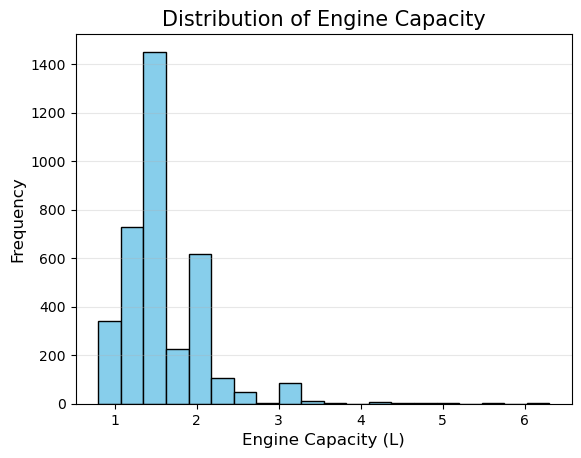

In [85]:
plt.hist(merged_df['Engine'].dropna(), bins=20, color='skyblue', edgecolor='black')

# 2. 그래프 제목 및 축 이름 설정 (키워드 인자 활용)
plt.title('Distribution of Engine Capacity', fontsize=15)
plt.xlabel('Engine Capacity (L)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 3. 그리드 추가
plt.grid(axis='y', alpha=0.3)

# 4. 그래프 출력 또는 저장
plt.savefig('engine_histogram.png')

In [87]:
merged_df['Engine'].isnull().sum()

np.int64(45)

In [ ]:
merged_df['Engine'].isnull().mean()  #1.2퍼센트에 해당하는 결측치를 어떻게 할지?

np.float64(0.012205044751830757)

In [89]:
# 'Engine' 컬럼이 비어 있는 데이터들만 모아서 별도의 데이터프레임으로 보기

# 'Engine' 컬럼이 NaN인 데이터만 필터링하여 따로 저장
engine_na_rows = merged_df[merged_df['Engine'].isna()]

# 상위 10개만 출력해서 살펴보기
print(engine_na_rows.head(45))

                   title     brand      model  Price  Mileage(miles)  \
679         BMW 3 SERIES       BMW   3 SERIES   4200           68060   
835        TOYOTA MARK X    TOYOTA     MARK X   7500           77000   
856         NISSAN CUBIC    NISSAN      CUBIC   4500           47000   
1087             AUDI A1      AUDI         A1   7995           50500   
1304        MAZDA MAZDA6     MAZDA     MAZDA6   1500          155670   
1429          FORD FOCUS      FORD      FOCUS   1895          109000   
1533          CITROEN C1   CITROEN         C1   3900           71000   
1619             FORD KA      FORD         KA   2490           68837   
2022             AUDI A3      AUDI         A3   5750          139225   
2136        TOYOTA PRIUS    TOYOTA      PRIUS   8950           66000   
2194         MAZDA MX-30     MAZDA      MX-30  13899           13865   
2288         NISSAN LEAF    NISSAN       LEAF   5390           60695   
2299         NISSAN LEAF    NISSAN       LEAF   5390           6

In [ ]:
engine_na_rows.isnull().sum()   # 엔진 열에 있는 결측치 행만 출력해서 다른 데이터가 비어있는지 확인

title                 0
brand                 0
model                 0
Price                 0
Mileage(miles)        0
Registration_Year     0
Previous Owners       0
Fuel type             0
Body type             0
Engine               45
Gearbox               0
Doors                10
Seats                10
Emission Class       44
Service history      42
country               0
dtype: int64

In [ ]:
###### 다른 결측치도 빠져 있어서, 45개 데이터를 제외하기로 함. ######

merged_df.dropna(subset=['Engine'], inplace=True)
print(merged_df['Engine'].isnull().sum()) 


0


#### 3. Doors

In [99]:
merged_df['Doors'].value_counts(dropna=False)

Doors
5.0    2310
3.0     734
4.0     367
2.0     216
NaN      15
Name: count, dtype: int64

In [ ]:
merged_df= merged_df.dropna(subset=['Doors'], axis=0)   #### Seats수로 Doors 수를 유추하기에는 무리가 있어서, 나머지 10개도 제거함
merged_df['Doors'].isnull().sum()

np.int64(0)

#### 4. Seats

In [116]:
merged_df['Seats'].value_counts(dropna=False)

Seats
5.0    2928
4.0     529
7.0     120
2.0      24
NaN      20
6.0       4
3.0       2
Name: count, dtype: int64

In [118]:
merged_df[merged_df['Seats'].isna()]

,title,brand,model,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country
8,VOLVO 740,VOLVO,740,750,225318,2025,3.0,Petrol,Estate,2.3,Automatic,5.0,NaN,NaN,NaN,Sweden
107,CITROEN XM,CITROEN,XM,3250,126000,1995,4.0,Diesel,Hatchback,2.5,Manual,5.0,NaN,Euro 2,NaN,France
229,MERCEDES-BENZ 260,MERCEDES-BENZ,260,2995,57400,1991,3.0,Petrol,Saloon,2.6,Automatic,4.0,NaN,NaN,NaN,Germany
237,MG MIDGET,MG,MIDGET,1875,75043,1972,3.0,Petrol,Convertible,1.3,Manual,2.0,NaN,NaN,NaN,United Kingdom
645,ROVER MINI,ROVER,MINI,1650,49309,1990,4.0,Petrol,Saloon,1.0,Automatic,2.0,NaN,NaN,NaN,United Kingdom
733,TOYOTA CAMRY,TOYOTA,CAMRY,2389,125000,1990,3.0,Petrol,Estate,2.0,Automatic,5.0,NaN,NaN,NaN,Japan
931,BMW 3 SERIES,BMW,3 SERIES,6700,105000,1999,7.0,Petrol,Coupe,2.5,Manual,2.0,NaN,Euro 2,NaN,Germany
1006,SAAB 900,SAAB,900,5995,157000,1992,5.0,Petrol,Convertible,2.0,Manual,2.0,NaN,Euro 1,NaN,Sweden
1053,VOLKSWAGEN GOLF,VOLKSWAGEN,GOLF,1250,110000,1996,3.0,Petrol,Convertible,2.0,Manual,2.0,NaN,Euro 1,NaN,Germany
1239,NISSAN SUNNY,NISSAN,SUNNY,999,60000,1985,3.0,Petrol,Saloon,1.3,Manual,4.0,NaN,NaN,NaN,Japan


In [131]:
merged_df= merged_df.dropna(subset=['Seats'], axis=0)

In [132]:
merged_df.isnull().sum()

title                 0
brand                 0
model                 0
Price                 0
Mileage(miles)        0
Registration_Year     0
Previous Owners       0
Fuel type             0
Body type             0
Engine                0
Gearbox               0
Doors                 0
Seats                 0
Emission Class       14
Service history       0
country               0
dtype: int64

#### 5. Emission Class

In [120]:
merged_df['Emission Class'].value_counts(dropna=False)

Emission Class
Euro 5    1256
Euro 6    1109
Euro 4    1068
Euro 3     137
NaN         28
Euro 2      25
Euro 1       4
Name: count, dtype: int64

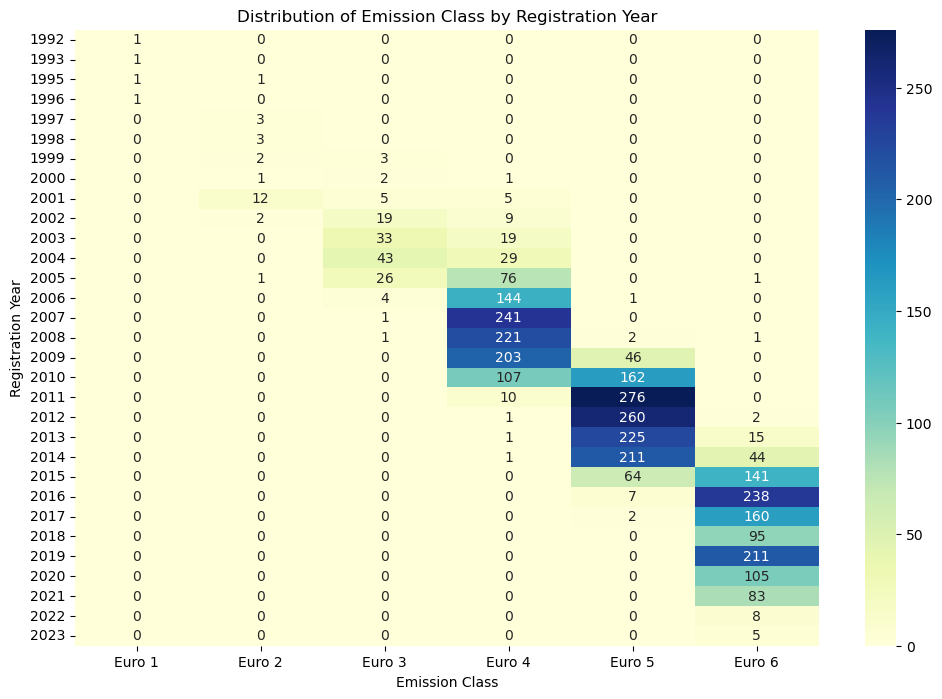

In [126]:
### Emission Class는 연식과 깊은 관계가 있다고 하여, Euro 등급과  차량 연식(Registration_Year)의 관계를 먼저 시각화 해봄 ######

# 1. 연도와 Emission Class 간의 교차 테이블 생성
emission_by_year = pd.crosstab(merged_df['Registration_Year'], merged_df['Emission Class'])

# 2. 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(emission_by_year, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Distribution of Emission Class by Registration Year')
plt.xlabel('Emission Class')
plt.ylabel('Registration Year')
plt.show()

In [127]:
# Emission Class가 NaN인 데이터들의 연도별 개수 확인
merged_df[merged_df['Emission Class'].isna()]['Registration_Year'].value_counts().sort_index()

Registration_Year
1953    1
1972    1
1985    1
1987    2
1988    2
1990    3
1991    2
1995    1
2008    1
2009    1
2010    1
2011    1
2012    5
2013    1
2015    1
2016    1
2017    1
2023    1
2025    1
Name: count, dtype: int64

In [136]:
merged_df['Emission Class'].describe()

count       3593
unique         6
top       Euro 5
freq        1256
Name: Emission Class, dtype: object

In [ ]:
#### 년도와 비교하여 유추하기 보다는 삭제하기로 결정함 ####
merged_df= merged_df.dropna(subset=['Emission Class'], axis=0)  

### 5. Service history

In [123]:
merged_df['Service history'].value_counts(dropna=False)

Service history
NaN     3091
Full     536
Name: count, dtype: int64

In [125]:
####### 결측치가 상당히 많으므로, Unknown/No'로 변환 ####### 

merged_df['Service history'] = merged_df['Service history'].fillna('Unknown')
merged_df['Service history'].value_counts(dropna=False)

Service history
Unknown    3091
Full        536
Name: count, dtype: int64

In [138]:
merged_df.isnull().sum()

title                0
brand                0
model                0
Price                0
Mileage(miles)       0
Registration_Year    0
Previous Owners      0
Fuel type            0
Body type            0
Engine               0
Gearbox              0
Doors                0
Seats                0
Emission Class       0
Service history      0
country              0
dtype: int64

## 2. 카테고리형 변수를 숫자 형태로 변환하기

In [167]:
### 결측치 제거 완료 확인  
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3588 entries, 0 to 3686
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   title                            3588 non-null   object 
 1   brand                            3588 non-null   object 
 2   model                            3588 non-null   object 
 3   Price                            3588 non-null   int64  
 4   Mileage(miles)                   3588 non-null   int64  
 5   Registration_Year                3588 non-null   int64  
 6   Previous Owners                  3588 non-null   int64  
 7   Engine                           3588 non-null   float64
 8   Doors                            3588 non-null   int64  
 9   Seats                            3588 non-null   int64  
 10  Emission Class                   3588 non-null   object 
 11  Service history                  3588 non-null   object 
 12  country                  

### 1. 수치형 칼럼 정제 (지수 표기법 해결 및 정수화)

##### Price

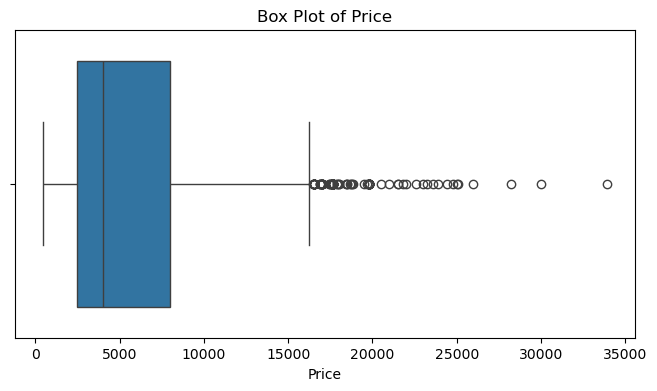

count     3588.000000
mean      5777.957637
std       4491.846179
min        450.000000
25%       2490.000000
50%       3999.000000
75%       7999.000000
max      33900.000000
Name: Price, dtype: float64


In [168]:
#Price 분포도를 그려보고 outlier 파악

# Price 박스 플롯 시각화
plt.figure(figsize=(8, 4))
sns.boxplot(x=merged_df['Price'])
plt.title('Box Plot of Price')
plt.show()

# 통계 요약 확인
print(merged_df['Price'].describe())

<Axes: xlabel='Log_Price'>

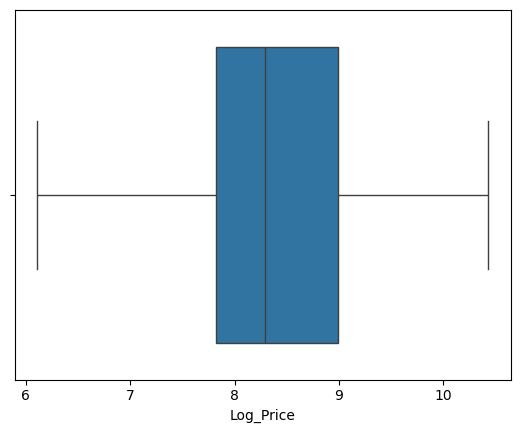

In [169]:
# 아웃라이어가 상당히 많이 존재하지만, 데이터를 삭제하는 IQR 방법 보다는 로그 변환을 시도해보자.
merged_df['Log_Price'] = np.log1p(merged_df['Price'])

# 변환 후 박스 플롯
sns.boxplot(x=merged_df['Log_Price'])

In [170]:
# 6 이하 즉, 400달러 
merged_df = merged_df[merged_df['Log_Price'] > 6]
print(f"Price 이상치 제거 후 남은 데이터: {len(merged_df)}개")

Price 이상치 제거 후 남은 데이터: 3588개


In [171]:
merged_df['Log_Price'].describe()

count    3588.000000
mean        8.373517
std         0.774023
min         6.111467
25%         7.820440
50%         8.294050
75%         8.987197
max        10.431200
Name: Log_Price, dtype: float64

In [172]:
merged_df['Price'].describe()

count     3588.000000
mean      5777.957637
std       4491.846179
min        450.000000
25%       2490.000000
50%       3999.000000
75%       7999.000000
max      33900.000000
Name: Price, dtype: float64

#### Mileage(miles) 

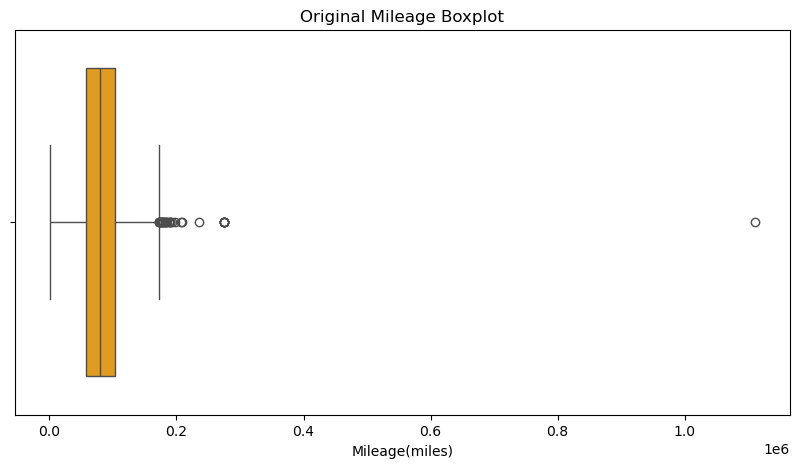

In [173]:
# Mileage(miles)  분포도를 그려보고 outlier 파악

# 2. Mileage(miles) 분포 확인 (로그 변환 전)
plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_df['Mileage(miles)'], color='orange')
plt.title('Original Mileage Boxplot')
plt.show()

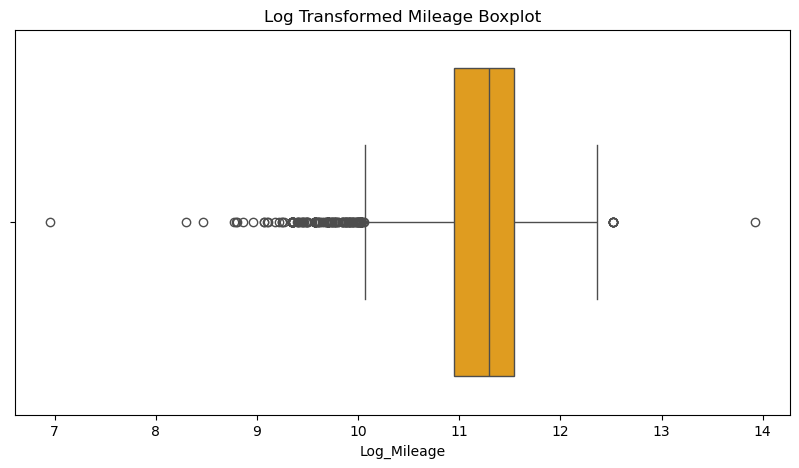

In [174]:
# 마찬가지로 로그 변환
# 마일리지는 0인 경우가 있을 수 있으므로 np.log1p (log(1+x))를 사용
merged_df['Log_Mileage'] = np.log1p(merged_df['Mileage(miles)'])



# 로그 변환 후 분포 확인
plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_df['Log_Mileage'], color='orange')
plt.title('Log Transformed Mileage Boxplot')
plt.show()

In [175]:
merged_df['Mileage(miles)'].value_counts(dropna=False).sort_index()

Mileage(miles)
1048       1
4000       1
4750       1
6461       1
6561       1
          ..
207734     1
208000     1
234680     1
274100     7
1110100    1
Name: count, Length: 1534, dtype: int64

In [176]:
# 이하인 데이터가 몇 개인지 확인
under_6 = merged_df[merged_df['Log_Mileage'] <= 6]
print(f"마일리지 400마일 이하 데이터 수: {len(under_6)}개")

# 확인 후 삭제
merged_df = merged_df[merged_df['Log_Mileage'] > 6]

마일리지 400마일 이하 데이터 수: 0개


#### 수치형 칼럼 마무리: 정수형 변환 (float -> int)

In [177]:
# 수치형 칼럼 마무리: 정수형 변환 (float -> int)
cols_to_fix = ['Previous Owners', 'Doors', 'Seats']
merged_df[cols_to_fix] = merged_df[cols_to_fix].astype(int)

### 2. 범주형(Category) 칼럼 숫자 변환

#### 1. 단순 이진 분류 (Binary Encoding) & 원-핫 인코딩 (One-Hot Encoding)

In [ ]:
# 범주가 적은 변수들 원-핫 인코딩
# drop_first=True는 다중공선성을 방지하기 위해 첫 번째 카테고리를 삭제한다.
merged_df = pd.get_dummies(merged_df, columns=['Gearbox', 'Fuel type', 'Body type'], drop_first=True)
print(merged_df.columns)

Index(['title', 'brand', 'model', 'Price', 'Mileage(miles)',
       'Registration_Year', 'Previous Owners', 'Engine', 'Doors', 'Seats',
       'Emission Class', 'Service history', 'country', 'Log_Price',
       'Log_Mileage', 'Gearbox_Manual', 'Fuel type_Diesel Hybrid',
       'Fuel type_Petrol', 'Fuel type_Petrol Hybrid',
       'Fuel type_Petrol Plug-in Hybrid', 'Body type_Convertible',
       'Body type_Coupe', 'Body type_Estate', 'Body type_Hatchback',
       'Body type_MPV', 'Body type_Pickup', 'Body type_SUV',
       'Body type_Saloon'],
      dtype='object')


## 4. Scaler 활용해보기

## 5. 기존 데이터의 정보 70% 이상을 가지는 수준에서 최소한의 주성분 추출 (PCA)


## 국가별 총 브랜드 개수는?

## 상관관계가 높은 변수들이 있는지 확인해보세요.